# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [2]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41
...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [4]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


In [5]:
df["month"].value_counts()

month
1     31
3     31
7     31
5     31
12    31
4     30
11    30
6     30
10    30
9     28
2     26
8     19
Name: count, dtype: int64

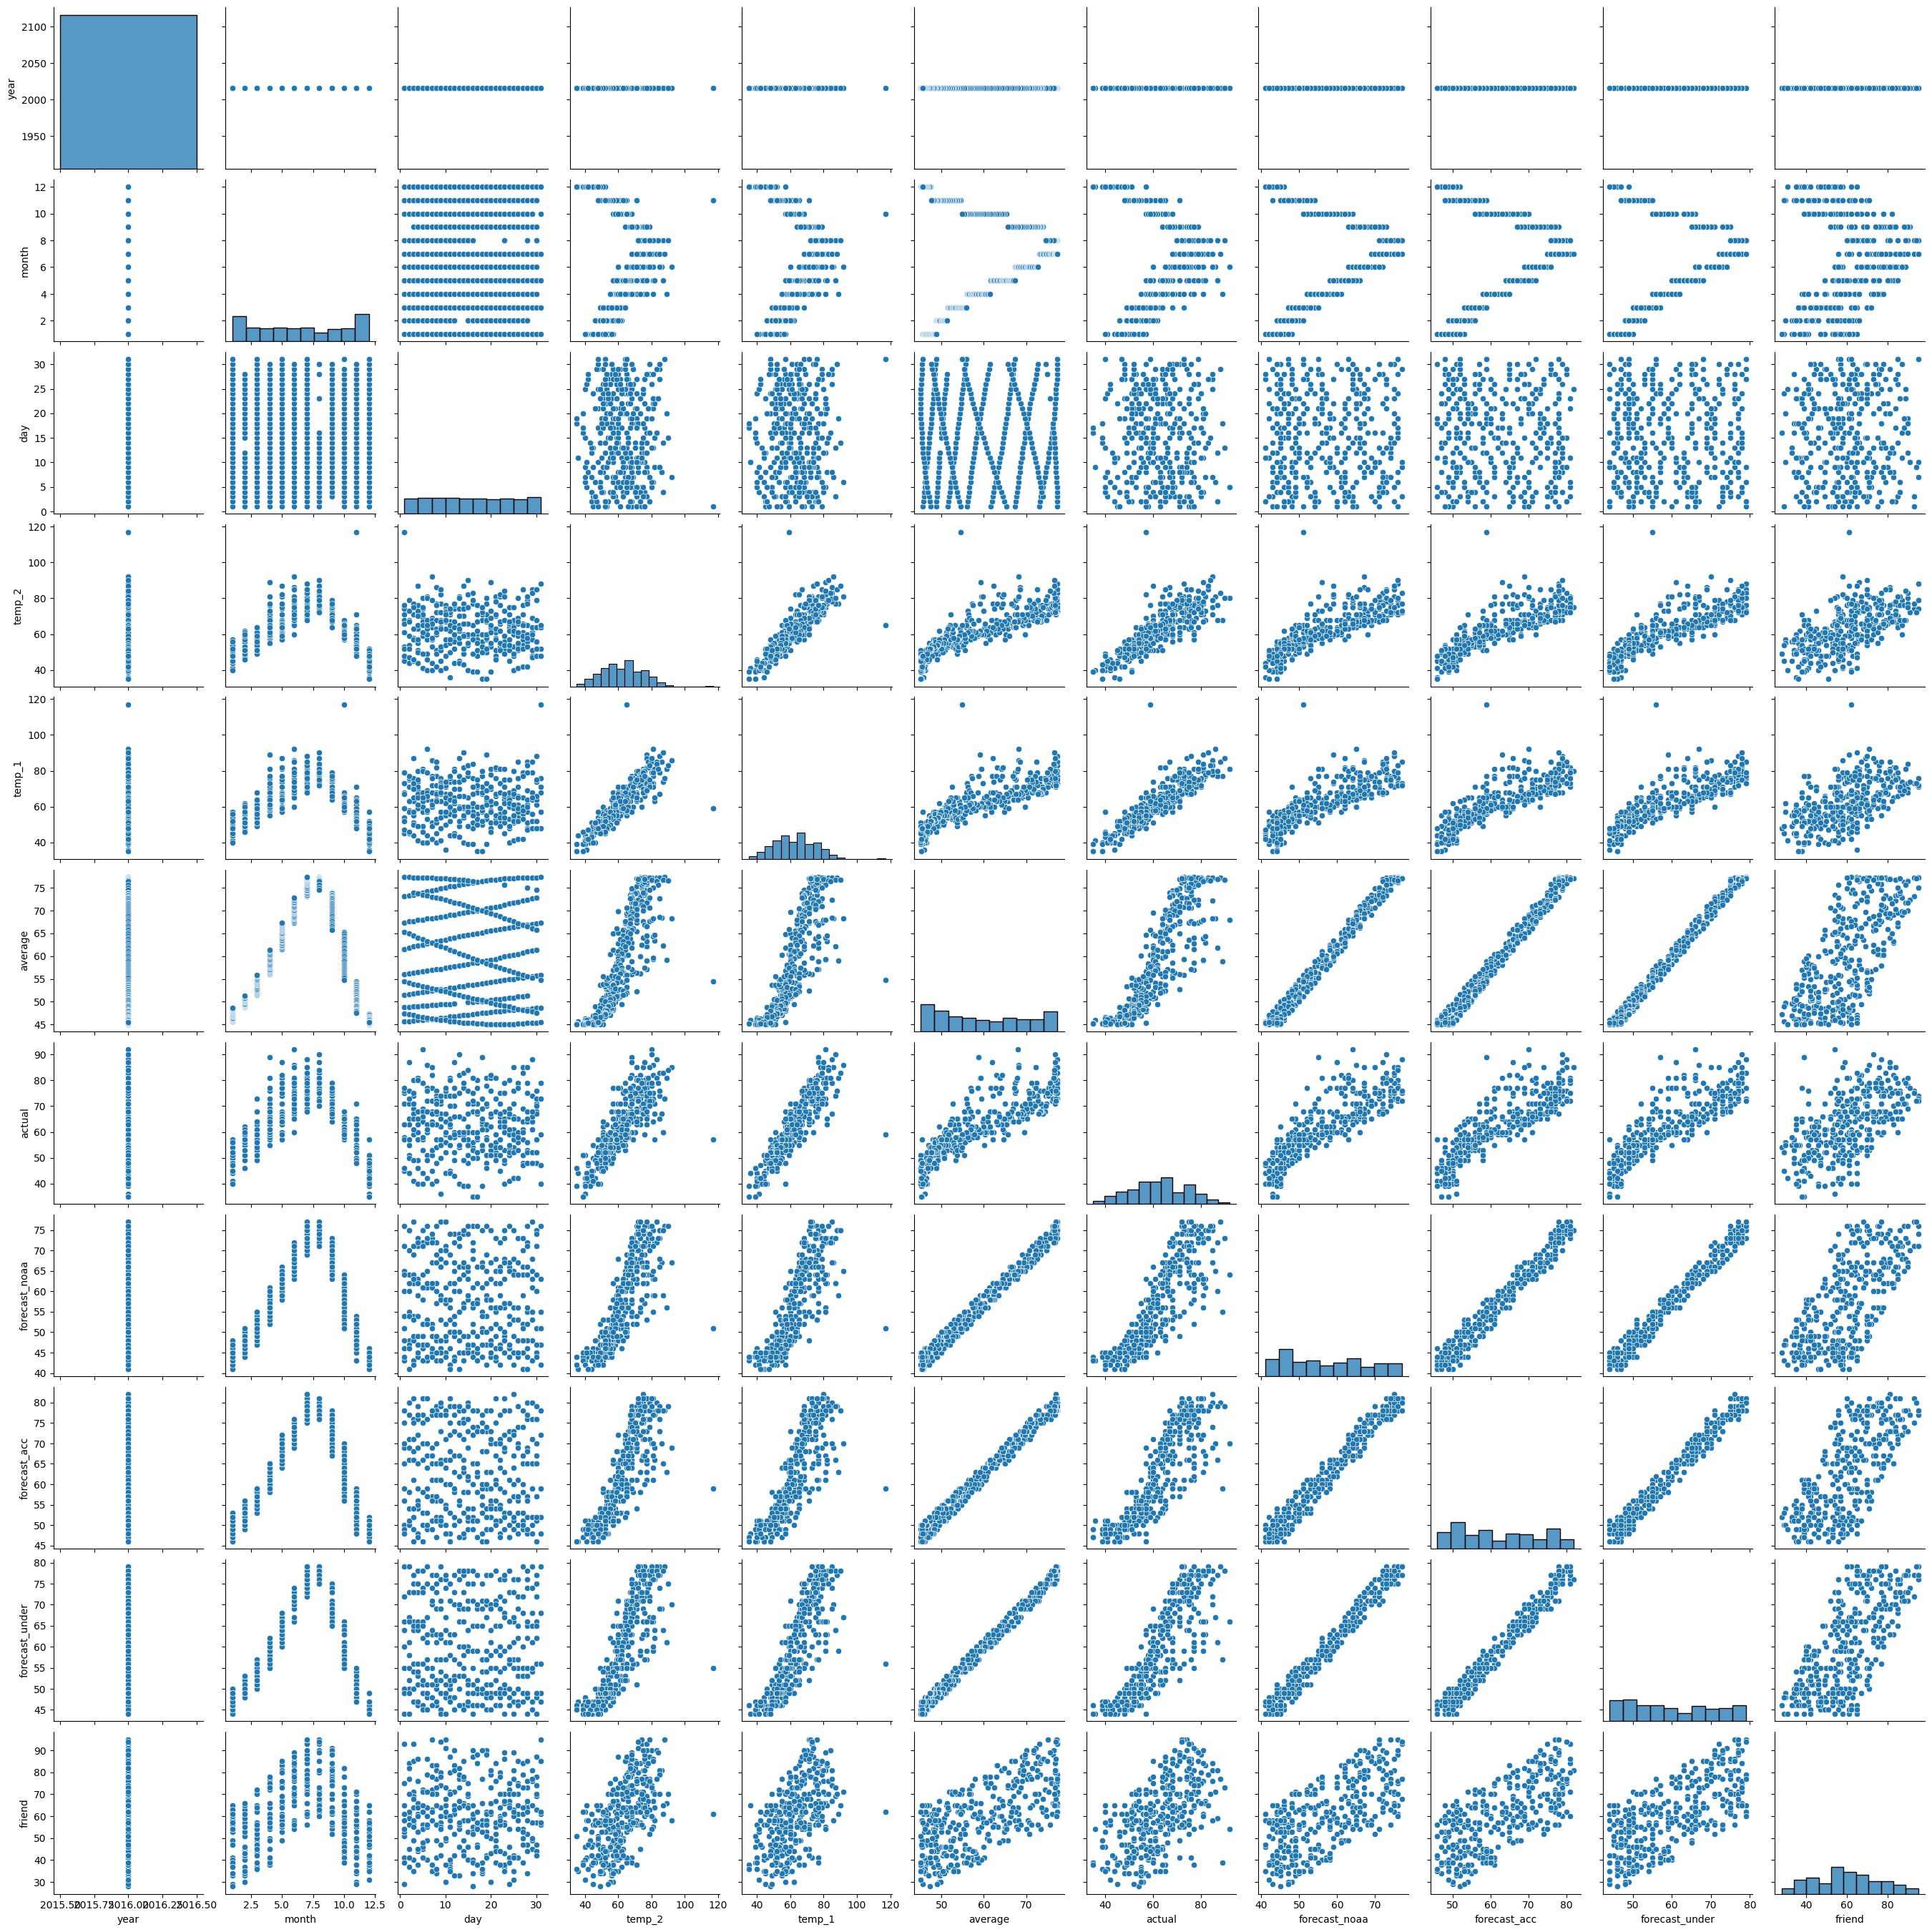

In [6]:
sns.pairplot(df)

<Axes: >

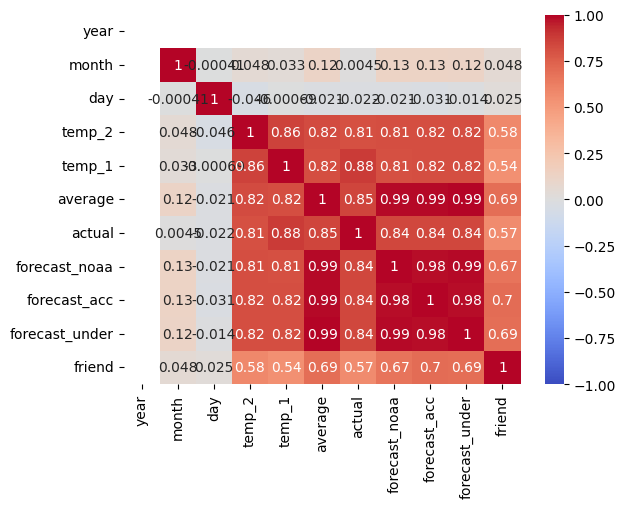

In [7]:
sns.heatmap(df.corr(numeric_only= True), annot= True, cmap="coolwarm", vmin=-1)

In [9]:
df["week"].value_counts()

week
Tues     52
Sat      50
Fri      50
Sun      49
Mon      49
Wed      49
Thurs    49
Name: count, dtype: int64

In [11]:
le = LabelEncoder()
df["weeek_int"] = le.fit_transform(df["week"])
df


,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,weeek_int
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0


In [12]:
semana = {
    "Mon": 1,
    "Tues":2, 
    "Wed": 3,  
    "Thurs": 4,
    "Fri": 5,
    "Sat": 6, 
    "Sun": 7
}

df["weeek_int_2"] =df["week"].replace(semana)
df

C:\Users\Diego Nuñez\AppData\Local\Temp\ipykernel_412\3414783891.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["weeek_int_2"] =df["week"].replace(semana)


,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,weeek_int,weeek_int_2
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0,5
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2,6
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3,7
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5,2
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6,3
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0,5


In [13]:
pd.get_dummies(df["week"])

,Fri,Mon,Sat,Sun,Thurs,Tues,Wed
0,True,False,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...
343,False,False,False,False,False,True,False
344,False,False,False,False,False,False,True
345,False,False,False,False,True,False,False
346,True,False,False,False,False,False,False


<Axes: >

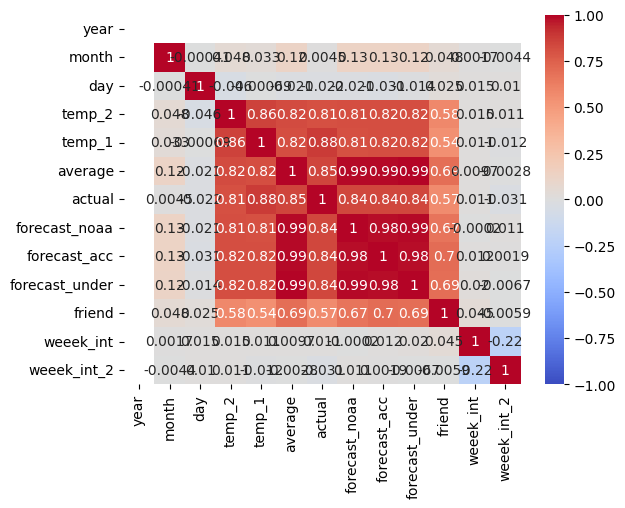

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot= True, vmin=-1, cmap = "coolwarm")

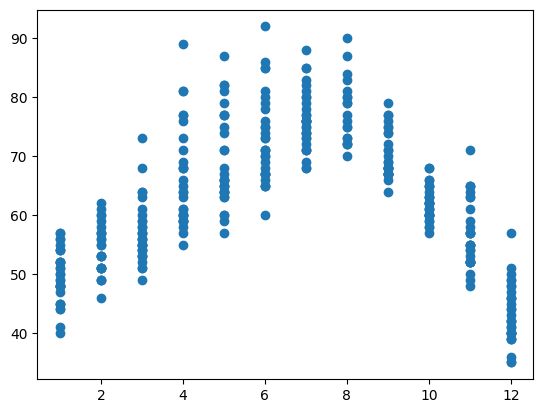

In [16]:
plt.scatter(df["month"], df["actual"])

### 3. Selecciona variables y divide en train y test

In [18]:
X = df[["temp_2", "temp_1", "average"]]
y = df["actual"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.15, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(295, 3)
(295,)
(53, 3)
(53,)


### 4. Entrena el modelo


In [20]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)

DecisionTreeRegressor()

In [21]:
dtr.score(X_train, y_train)

1.0

In [22]:
dtr.score(X_test, y_test)

0.7346952409583936

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [23]:
pred = dtr.predict(X_test)

print("MAE: ",metrics.mean_absolute_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))

MAE:  4.830188679245283
MAPE:  0.07284973572264618
MSE:  39.58490566037736
RMSE:  6.2916536507008525


### 6. Representa el árbol de decisión

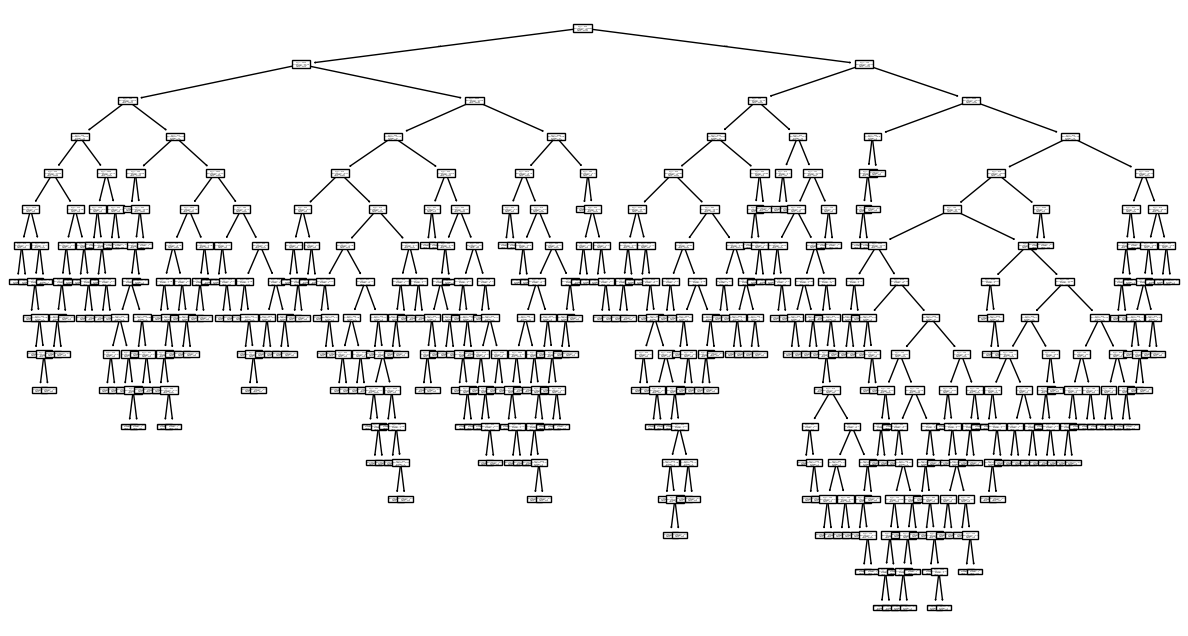

In [27]:
plt.figure(figsize=(15, 8))
plot_tree(dtr);

In [28]:
dtr.feature_importances_

array([0.04751966, 0.74779753, 0.20468282])

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [33]:
dtr_2 = DecisionTreeRegressor(max_depth=3)
dtr_2.fit(X_train, y_train)

print(dtr_2.score(X_train, y_train))



0.8404278014084332


### 8. Vuelve a evaluar tu modelo

In [34]:
pred = dtr_2.predict(X_test)

print("MAE: ",metrics.mean_absolute_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))

MAE:  4.237899543119572
MAPE:  0.06452826853087032
MSE:  26.39678215980319
RMSE:  5.1377798862741475


### 9. Vuelve a representar su árbol

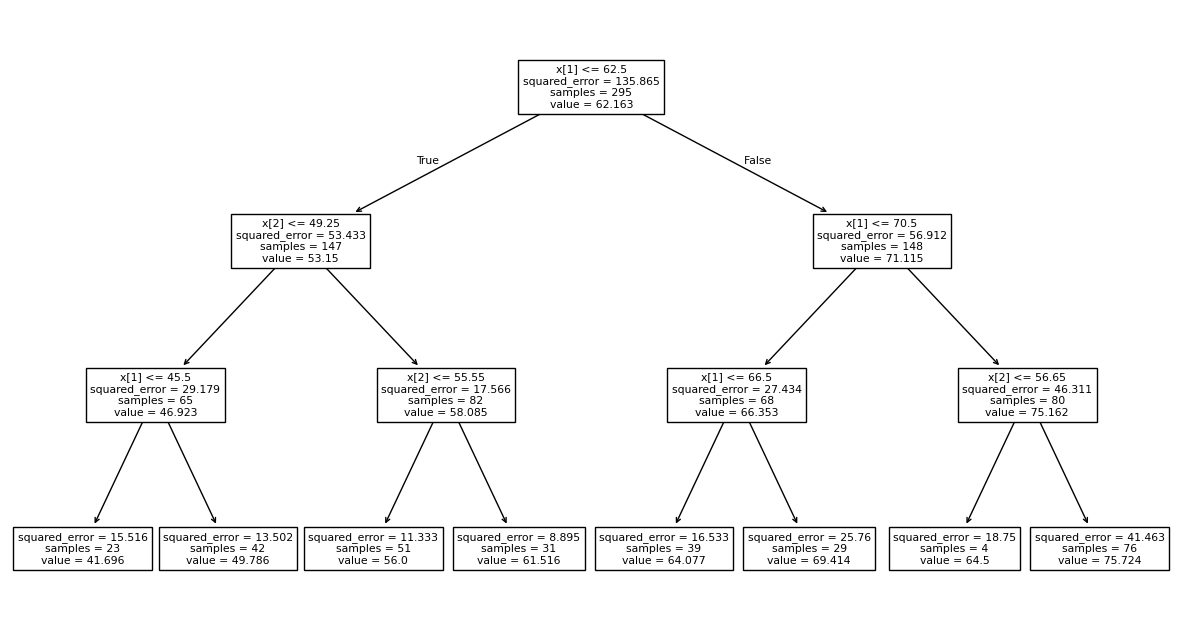

In [36]:
plt.figure(figsize=(15, 8))
plot_tree(dtr_2);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [42]:
parametros = {
    "max_depth": np.arange(2,8),
    "min_samples_leaf": [5,10,15,20], 
    "criterion": ["squared_error", "absolute_error"]
}

dtr = DecisionTreeRegressor(random_state= 42)

dtr_gs = GridSearchCV(dtr, parametros, cv = 3, scoring="neg_mean_absolute_error", verbose = 3)

In [43]:
dtr_gs.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV 1/3] END criterion=squared_error, max_depth=2, min_samples_leaf=5;, score=-5.025 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=2, min_samples_leaf=5;, score=-4.204 total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=2, min_samples_leaf=5;, score=-4.886 total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=2, min_samples_leaf=10;, score=-5.025 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=2, min_samples_leaf=10;, score=-4.204 total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=2, min_samples_leaf=10;, score=-4.886 total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=2, min_samples_leaf=15;, score=-5.025 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=2, min_samples_leaf=15;, score=-4.204 total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=2, min_samples_leaf=15;, score=-4.886 total time=   0

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': array([2, 3, 4, 5, 6, 7]),
                         'min_samples_leaf': [5, 10, 15, 20]},
             scoring='neg_mean_absolute_error', verbose=3)

In [44]:
print("Modelo: ", dtr_gs.best_estimator_)
print("Score: ", dtr_gs.best_score_)

Modelo:  DecisionTreeRegressor(max_depth=np.int64(4), min_samples_leaf=15,
                      random_state=42)
Score:  -4.0033237408586055


In [45]:
dtc_final = dtr_gs.best_estimator_

pred = dtc_final.predict(X_test)

In [46]:
print("MAE: ",metrics.mean_absolute_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("MSE: ", metrics.mean_squared_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))

MAE:  4.140148668740368
MAPE:  0.0627668320869185
MSE:  24.136495310582234
RMSE:  4.912890728540808


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [47]:
dtc_final.feature_importances_

array([0.       , 0.8313908, 0.1686092])

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [51]:
df[df["actual"] <= 15]

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,weeek_int,weeek_int_2


In [53]:
df["actual_class"] = np.where(df["actual"]>59, 1, 0)
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,weeek_int,weeek_int_2,actual_class
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0,5,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2,6,0
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3,7,0
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,1,0
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5,2,0
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6,3,0
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,4,0
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0,5,0


In [57]:
df["actual_class"].value_counts(normalize= True)

actual_class
1    0.586207
0    0.413793
Name: proportion, dtype: float64

In [ ]:
X = df[["temp_2", "temp_1", "average"]]
y = df["actual_class"]

--------- MEJOR MODELO------------
Modelo:  DecisionTreeClassifier(max_depth=np.int64(4), min_samples_leaf=5,
                       random_state=42)
Score:  0.9019102590531162
Accuracy:  0.9245283018867925
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.94      0.94      0.94        34

    accuracy                           0.92        53
   macro avg       0.92      0.92      0.92        53
weighted avg       0.92      0.92      0.92        53



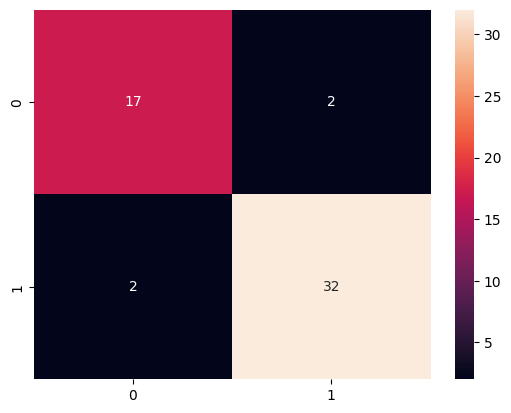

In [74]:
X = df[["temp_2", "temp_1", "average"]]
y = df["actual_class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=11)

parametros = {
    "max_depth": np.arange(2,8),
    "min_samples_leaf": [5,10,15,20], 
}

dtr = DecisionTreeClassifier(random_state= 42)

dtr_gs = GridSearchCV(dtr, parametros, cv = 3, scoring="accuracy", verbose = 0)
dtr_gs.fit(X_train, y_train)


print("--------- MEJOR MODELO------------")
print("Modelo: ", dtr_gs.best_estimator_)
print("Score: ", dtr_gs.best_score_)

dtc_final = dtr_gs.best_estimator_
pred = dtc_final.predict(X_test)

print("Accuracy: ", metrics.accuracy_score(y_test, pred))

print(metrics.classification_report(y_test, pred))

sns.heatmap(metrics.confusion_matrix(y_test, pred), annot=True);



In [72]:
print(metrics.classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.91      0.95        34

    accuracy                           0.94        53
   macro avg       0.93      0.96      0.94        53
weighted avg       0.95      0.94      0.94        53

